In [63]:
import polars as pl
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 12

MODULO=1009
!mkdir -p images

## Сравнение хэшей

In [258]:
def read_data_array(filename, apply_fn):
    with open(filename, 'r') as f:
        rn_uints = f.readline().strip()
    return list(map(apply_fn, rn_uints[:-2].split(' ')))
def get_hash_values(arr):
    idxs, counts = np.unique(arr, return_counts=True)
    zrs = np.zeros(MODULO, dtype="int")
    zrs[idxs] = counts
    return zrs
    

def plot_bars(arr, ax=None):
    counts = get_hash_values(arr)
    if ax is None:
        ax = plt.gca()
        
    ax.bar(x=np.arange(MODULO), height=counts)
    ax.set(xlabel="Hash buckets", ylabel="Count")
    
def plot_bivariatemap(arr, ax=None):
    counts = get_hash_values(arr)
    ax = sns.histplot(x=np.arange(MODULO), y=counts, ax=ax)
    ax.set(xlabel="Hash buckets", ylabel="Count")


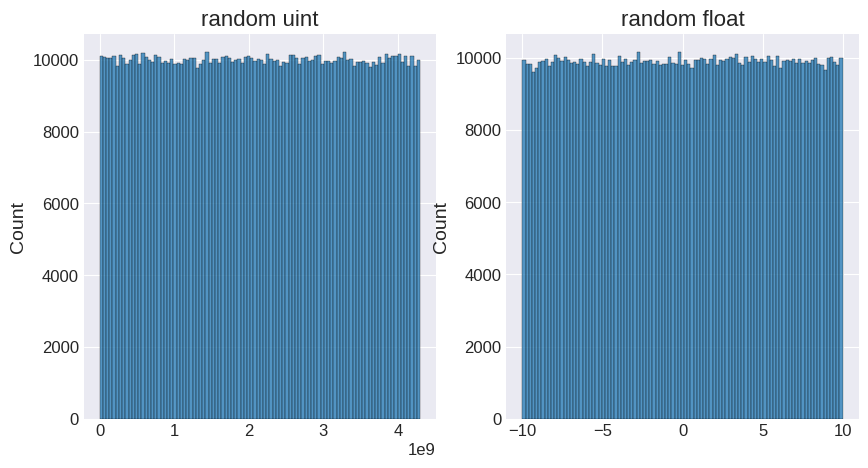

In [253]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.histplot(read_data_array('tests/random_uint.in', int), ax=axes[0]).set(title="random uint")
sns.histplot(read_data_array('tests/random_float.in', float), ax=axes[1]).set(title="random float")

plt.savefig('images/random_check.png')
plt.show()

### UINT Hashing functions

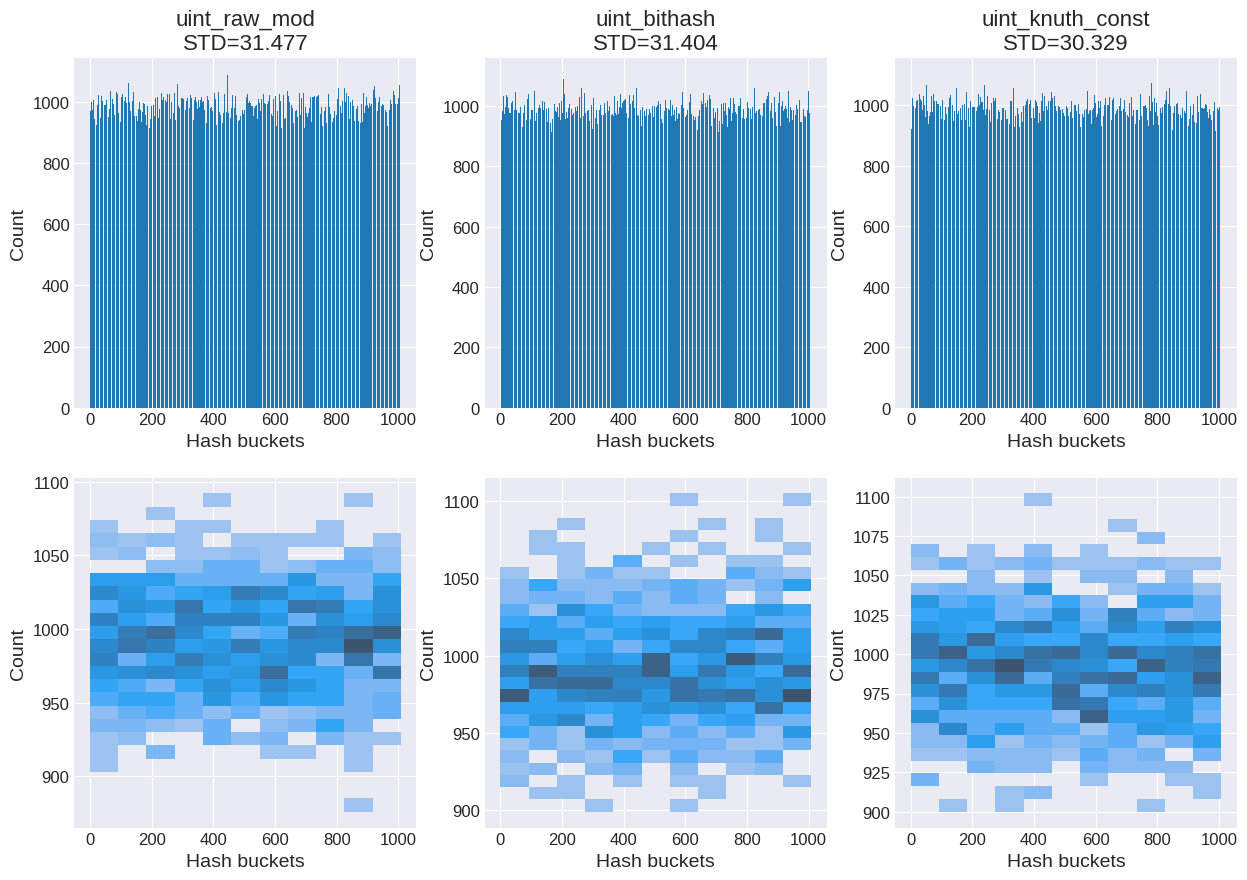

In [254]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
stat_files = ['reports/uint_raw_mod.out', 'reports/uint_bithash.out', 'reports/uint_knuth_const.out']

for i, fl in enumerate(stat_files):
    data = read_data_array(fl, int)
    plot_bars(data, ax=axes[0][i])
    plot_bivariatemap(data, ax=axes[1][i])

    counts = get_hash_values(data)
    std_deviation = np.std(counts)

    plot_name = fl.replace('reports/', '').replace('.out', '')
    axes[0][i].set(title=f"{plot_name}\nSTD={std_deviation:.3f}")

plt.savefig('images/uint_hashes.png')
plt.show()

### Float Hashing functions

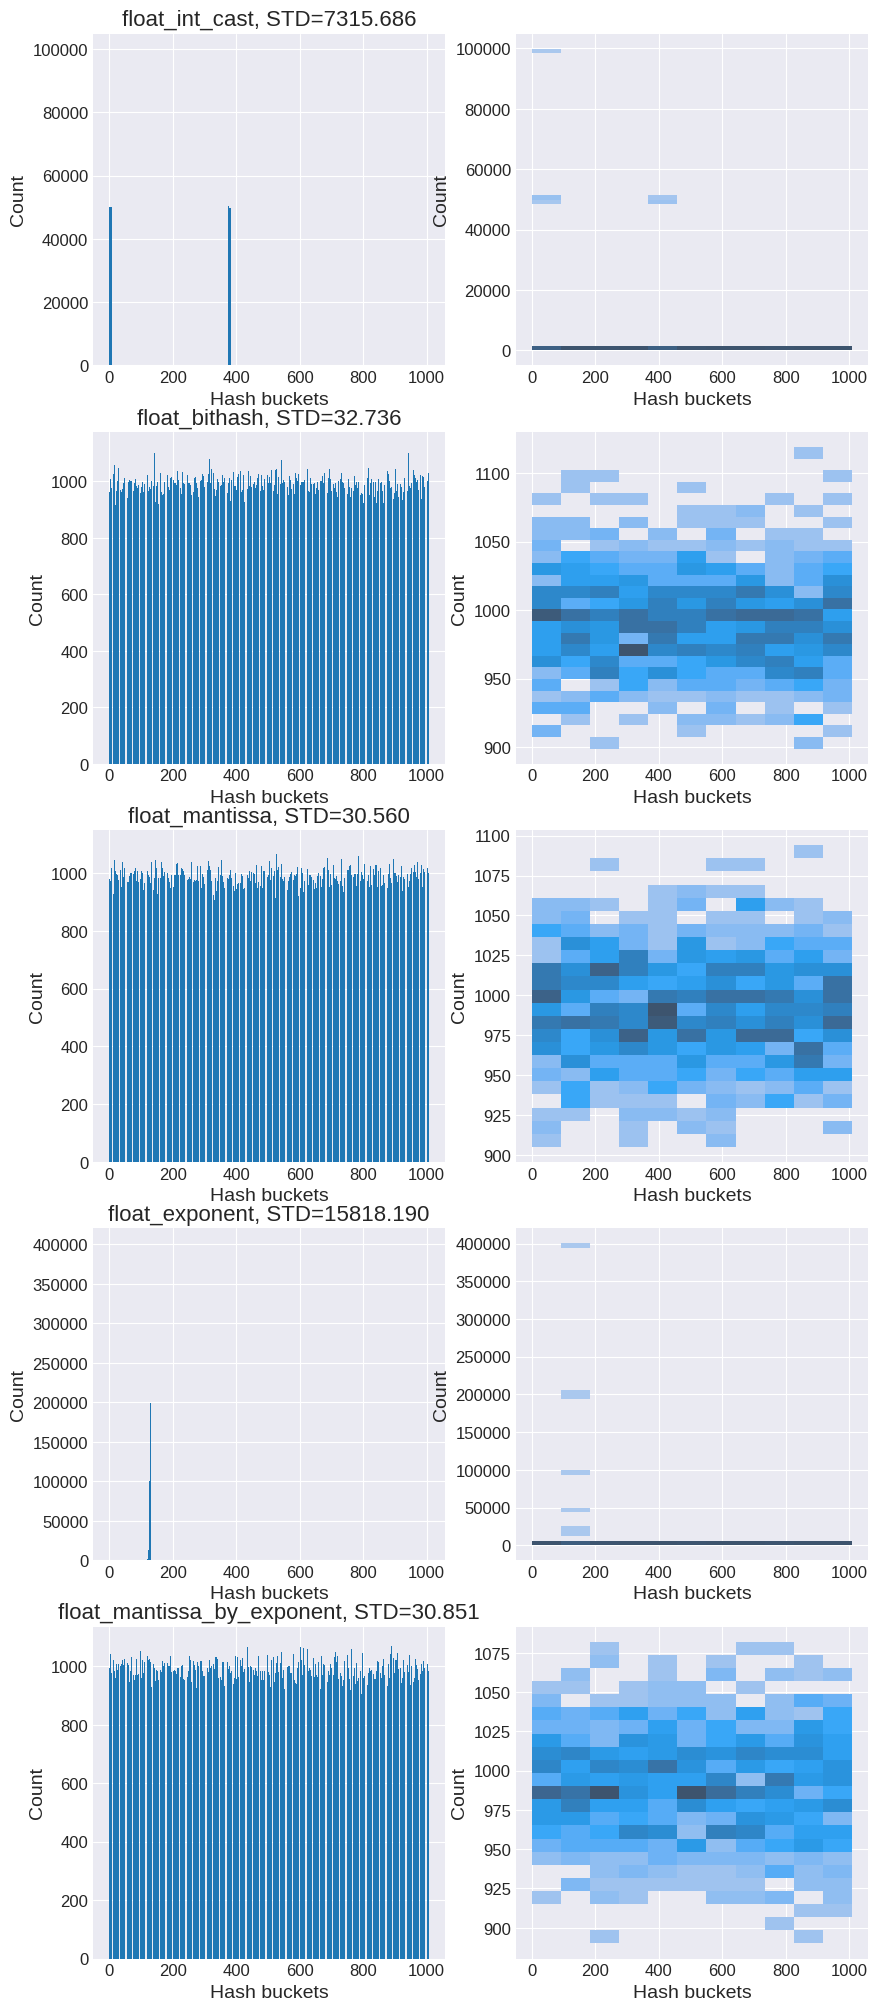

In [255]:
fig, axes = plt.subplots(5, 2, figsize=(10, 25))

stat_files = ['reports/float_int_cast.out', 'reports/float_bithash.out', 'reports/float_mantissa.out',
             'reports/float_exponent.out', 'reports/float_mantissa_by_exponent.out']

for i, fl in enumerate(stat_files):
    data = read_data_array(fl, int)
    plot_bars(data, ax=axes[i][0])
    plot_bivariatemap(data, ax=axes[i][1])

    counts = get_hash_values(data)
    std_deviation = np.std(counts)

    plot_name = fl.replace('reports/', '').replace('.out', '')
    axes[i][0].set(title=f"{plot_name}, STD={std_deviation:.3f}")

plt.savefig('images/float_hashes.png')
plt.show()


### STR Hashings

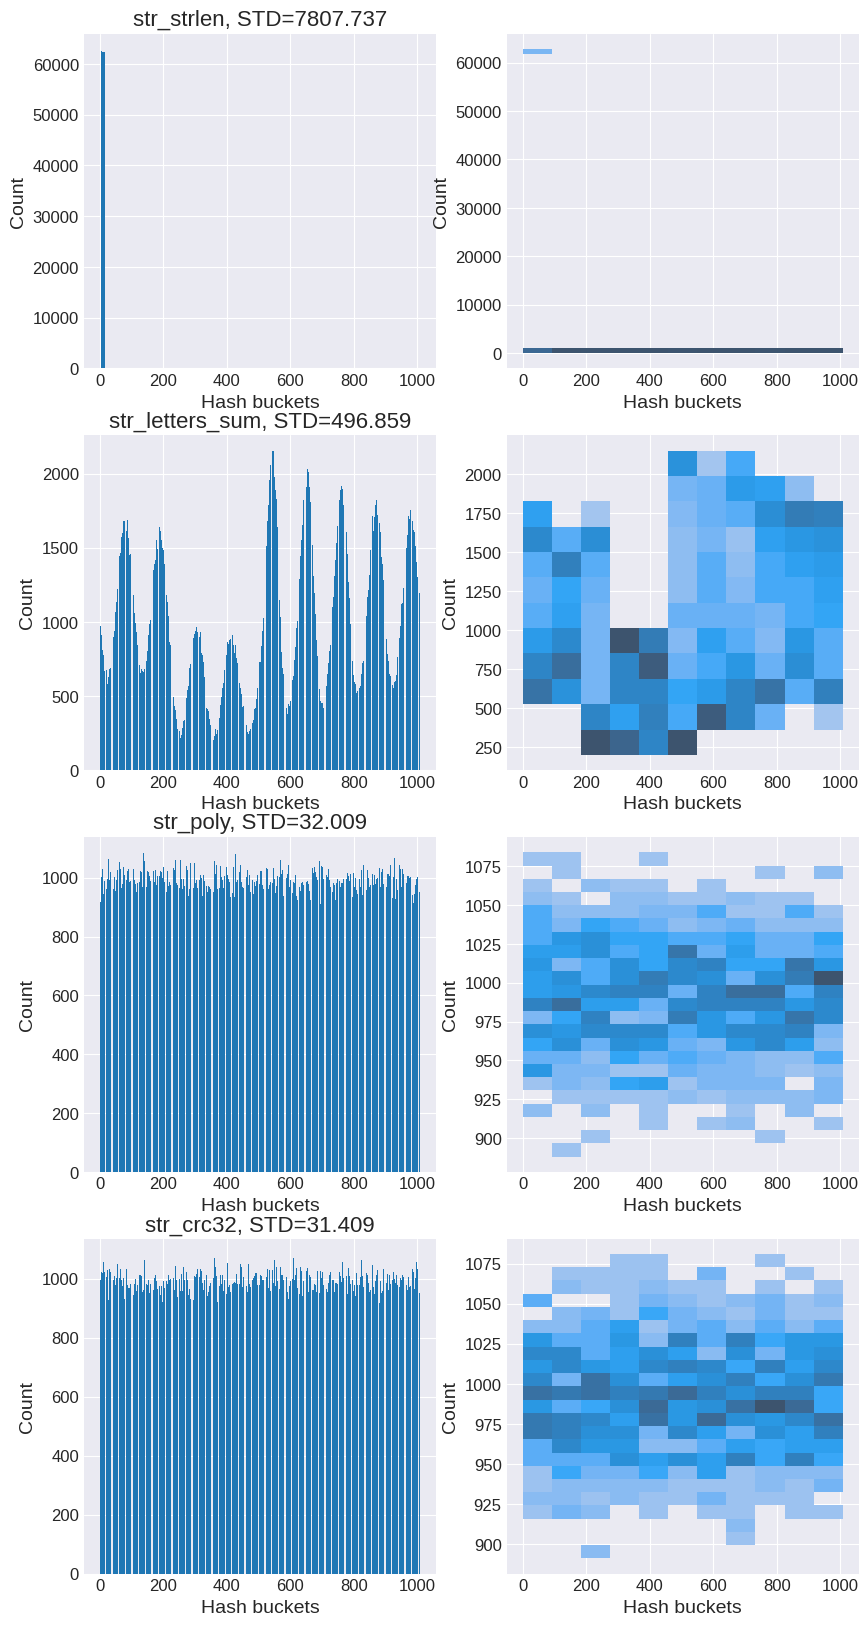

In [256]:
fig, axes = plt.subplots(4, 2, figsize=(10, 20))

stat_files = ['reports/str_strlen.out', 'reports/str_letters_sum.out', 'reports/str_poly.out',
             'reports/str_crc32.out']

for i, fl in enumerate(stat_files):
    data = read_data_array(fl, int)
    plot_bars(data, ax=axes[i][0])
    plot_bivariatemap(data, ax=axes[i][1])

    counts = get_hash_values(data)
    std_deviation = np.std(counts)

    plot_name = fl.replace('reports/', '').replace('.out', '')
    axes[i][0].set(title=f"{plot_name}, STD={std_deviation:.3f}")

plt.savefig('images/str_hashes.png')
plt.show()

## Сравнение хештаблиц

In [64]:
data = pl.read_csv('reports/hashtables_report.csv')

In [66]:
hashtable_types = data.group_by('optim_strat', maintain_order=True).len()['optim_strat'].to_list()
hashtable_types

['',
 'crc32',
 'asm_strcmp',
 'crc32 asm_strcmp',
 'strlen',
 'asm_strcmp strlen',
 'crc32 strlen',
 'crc32 asm_strcmp strlen']

In [67]:
data = data.with_columns(pl.col('optim_strat').replace("", "no_optims"))
data

optim_strat,ith_test,time
str,i64,f64
"""no_optims""",1,2070.724197
"""no_optims""",2,2191.593595
"""no_optims""",3,2156.142482
"""no_optims""",4,2111.092853
"""no_optims""",5,2108.040333
…,…,…
"""crc32 asm_strcmp strlen""",3,1433.366194
"""crc32 asm_strcmp strlen""",4,1384.50732
"""crc32 asm_strcmp strlen""",5,1407.54171


In [14]:
# .filter(pl.col('case').is_in(boxplot_lookup_cases))

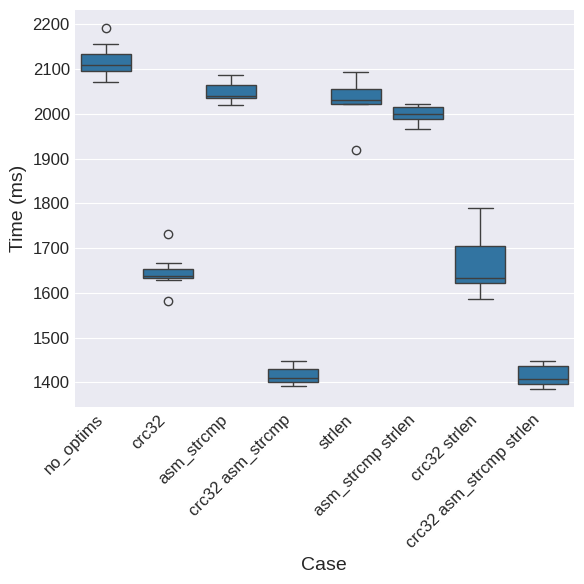

In [68]:
plt.figure(figsize=(6, 6))
sns.boxplot(data=data, x='optim_strat', y='time')

plt.xticks(rotation=45, ha='right')

plt.xlabel('Case')
plt.ylabel('Time (ms)')

plt.tight_layout()
plt.show()



In [69]:
median_data = data.group_by('optim_strat', maintain_order=True).median().select('optim_strat', 'time')
median_data.join(median_data, how='cross', maintain_order='left').with_columns((100. - (pl.col('time')/pl.col('time_right')) * 100.).alias('time_coeff'))\
    .pivot('optim_strat_right', index='optim_strat', values='time_coeff')

optim_strat,no_optims,crc32,asm_strcmp,crc32 asm_strcmp,strlen,asm_strcmp strlen,crc32 strlen,crc32 asm_strcmp strlen
str,f64,f64,f64,f64,f64,f64,f64,f64
"""no_optims""",0.0,-28.68992,-3.309728,-49.459991,-3.777945,-5.433695,-29.026546,-49.767521
"""crc32""",22.293836,0.0,19.721974,-16.139626,19.35814,18.07152,-0.26158,-16.378596
"""asm_strcmp""",3.203694,-24.567088,0.0,-44.67175,-0.453217,-2.055922,-24.89293,-44.969428
"""crc32 asm_strcmp""",33.092462,13.896743,30.878005,0.0,30.564732,29.45691,13.671515,-0.205761
"""strlen""",3.640412,-24.005076,0.451172,-44.019032,0.0,-1.595475,-24.329449,-44.315367
"""asm_strcmp strlen""",5.153661,-22.057677,2.014506,-41.75733,1.570419,0.0,-22.376955,-42.049011
"""crc32 strlen""",22.496569,0.260897,19.931417,-15.836621,19.568533,18.285269,0.0,-16.074967
"""crc32 asm_strcmp strlen""",33.229849,14.073546,31.019939,0.205338,30.70731,29.601763,13.84878,0.0
